In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
from IQAEBinom_FinalRoundRedo import IQAEBinom_FinalRoundRedo
import matplotlib.pyplot as plt
import pickle
import datetime
import os
import pandas as pd

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
ps = np.linspace(0.001, 0.999, 201)

In [4]:
errAvgs = np.array([])
errStds = np.array([])
biasesMonte = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results = np.array([])

    for i in range(nEstim):
        # if i % 100 == 0:
        #     print(i, datetime.datetime.now())
        result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff", endCriterion="Angle")
        results = np.append(results, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230911_VariousP_EndCondTheta/results_IQAE_pTrue" + str(p) + "_epsilon0001_alpha005.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results, f) 
    errs = [r["Estimate"] - p for r in results]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))


0.001 2023-09-11 18:11:47.401250
0.00599 2023-09-11 18:13:11.720462
0.01098 2023-09-11 18:15:26.362156
0.015969999999999998 2023-09-11 18:17:03.130269
0.02096 2023-09-11 18:18:41.339775
0.02595 2023-09-11 18:20:31.740240
0.03094 2023-09-11 18:22:55.619735
0.03593 2023-09-11 18:25:25.392131
0.04092 2023-09-11 18:27:40.339104
0.04591 2023-09-11 18:29:42.630424
0.0509 2023-09-11 18:31:37.392576
0.055889999999999995 2023-09-11 18:33:39.717275
0.06088 2023-09-11 18:35:35.892716
0.06587 2023-09-11 18:37:37.788075
0.07085999999999999 2023-09-11 18:39:42.898804
0.07585 2023-09-11 18:41:46.197093
0.08084 2023-09-11 18:43:48.068678
0.08582999999999999 2023-09-11 18:45:53.834964
0.09082 2023-09-11 18:48:05.705364
0.09580999999999999 2023-09-11 18:50:20.488492
0.1008 2023-09-11 18:52:37.931415
0.10579 2023-09-11 18:54:46.000997
0.11077999999999999 2023-09-11 18:56:53.208690
0.11577 2023-09-11 18:59:11.270520
0.12075999999999999 2023-09-11 19:01:46.685139
0.12574999999999997 2023-09-11 19:04:22.408

In [13]:
errAvgs_FinalRedo = np.array([])
errStds_FinalRedo = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results_FinalRedo = np.array([])

    for i in range(nEstim):
        # if i % 100 == 0:
        #     print(i, datetime.datetime.now())
        result = IQAEBinom_FinalRoundRedo(p, epsilon, alpha, nShotUnit, confint_method="chernoff", endCriterion="Angle")
        results_FinalRedo = np.append(results_FinalRedo, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230911_VariousP_EndCondTheta_FinalRoundRedo/results_IQAEFinalRoundRedo_pTrue" + str(p) + "_epsilon0001_alpha005.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results_FinalRedo, f) 
    errs_FinalRedo = [r["Estimate"] - p for r in results_FinalRedo]
    errAvgs_FinalRedo = np.append(errAvgs_FinalRedo, np.mean(errs_FinalRedo))
    errStds_FinalRedo = np.append(errStds_FinalRedo, np.std(errs_FinalRedo))

0.001 2023-09-12 18:15:18.782926
0.00599 2023-09-12 18:17:00.794744
0.01098 2023-09-12 18:19:38.950690
0.015969999999999998 2023-09-12 18:21:35.358926
0.02096 2023-09-12 18:23:34.713779
0.02595 2023-09-12 18:25:38.744845
0.03094 2023-09-12 18:28:09.189067
0.03593 2023-09-12 18:30:49.971451
0.04092 2023-09-12 18:33:16.564798
0.04591 2023-09-12 18:35:34.616562
0.0509 2023-09-12 18:37:41.856342
0.055889999999999995 2023-09-12 18:40:17.184507
0.06088 2023-09-12 18:42:26.635778
0.06587 2023-09-12 18:44:36.154113
0.07085999999999999 2023-09-12 18:46:46.077097
0.07585 2023-09-12 18:48:54.884122
0.08084 2023-09-12 18:51:02.066091
0.08582999999999999 2023-09-12 18:53:12.133442
0.09082 2023-09-12 18:55:25.796292
0.09580999999999999 2023-09-12 18:57:49.179323
0.1008 2023-09-12 19:00:12.628154
0.10579 2023-09-12 19:02:21.358399
0.11077999999999999 2023-09-12 19:04:34.217841
0.11577 2023-09-12 19:06:56.259799
0.12075999999999999 2023-09-12 19:09:38.490485
0.12574999999999997 2023-09-12 19:12:29.611

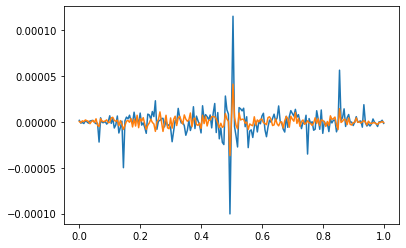

In [14]:
ax = plt.gca()
plt.plot(ps, errAvgs, label="Org")
plt.plot(ps, errAvgs_FinalRedo, label="FinalRedo")
plt.show()

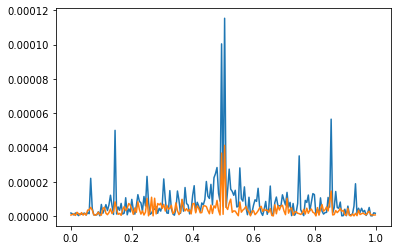

In [15]:
ax = plt.gca()
plt.plot(ps, np.abs(errAvgs), label="Org")
plt.plot(ps, np.abs(errAvgs_FinalRedo), label="FinalRedo")
plt.show()

In [16]:
resDf = pd.DataFrame({"P":ps, "ErrMean":errAvgs, "ErrMeanAbs":np.abs(errAvgs)})
resDf.sort_values("ErrMeanAbs", ascending=False)[:30]

,P,ErrMean,ErrMeanAbs
101,0.50499,0.000115,0.000115
99,0.49501,-0.000100,0.000100
171,0.85429,0.000056,0.000056
29,0.14571,-0.000050,0.000050
150,0.74950,-0.000035,0.000035
96,0.48004,0.000028,0.000028
111,0.55489,-0.000028,0.000028
104,0.51996,-0.000027,0.000027
95,0.47505,-0.000025,0.000025
50,0.25050,0.000023,0.000023


クエリ数の集計

In [28]:
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230911_VariousP_EndCondTheta"
files = os.listdir(dirPath)
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

totQueryNums = []

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    totQueryNums.append([r["TotalOracleCalls"] for r in res])

['results_IQAE_pTrue0.001_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.00599_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.01098_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.015969999999999998_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02096_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.02595_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03094_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.03593_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04092_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.04591_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.0509_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.055889999999999995_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06088_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.06587_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07085999999999999_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.07585_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08084_epsilon0001_alpha005.dat', 'results_IQAE_pTrue0.08582999999999999_epsilon

In [25]:
dirPath = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230911_VariousP_EndCondTheta_FinalRoundRedo"
files = os.listdir(dirPath)
print(files)

psInFiles = np.array([])
for f in files:
    psInFiles = np.append(psInFiles, float(f.split('_')[2][5:]))

print(psInFiles)

totQueryNums_FinalRedo = []

for p in ps:
    print(p)
    idRes = np.where(np.abs(psInFiles - p) < 1e-6)[0]
    if len(idRes) != 1:
        raise Exception("multiple ID:p=" + str(p) + ", ID=" + str(idRes))
    with open(dirPath + "/" + files[idRes[0]], 'rb') as f:
        res = pickle.load(f)
    totQueryNums_FinalRedo.append([r["TotalOracleCalls"] for r in res])

['results_IQAEFinalRoundRedo_pTrue0.001_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.00599_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.01098_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.015969999999999998_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.02096_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.02595_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.03094_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.03593_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.04092_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.04591_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.0509_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.055889999999999995_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.06088_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundRedo_pTrue0.06587_epsilon0001_alpha005.dat', 'results_IQAEFinalRoundR

In [29]:
aveQueryNum = [np.mean(t) for t in totQueryNums]
aveQueryNum_FinalRedo = [np.mean(t) for t in totQueryNums_FinalRedo]

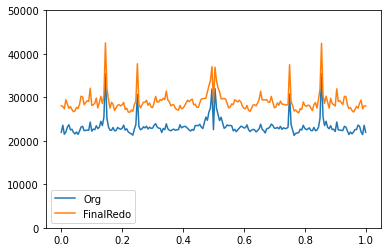

In [34]:
ax = plt.gca()
plt.plot(ps, aveQueryNum, label="Org")
plt.plot(ps, aveQueryNum_FinalRedo, label="FinalRedo")
plt.legend()
ax.set_ylim(0,50000)
plt.show()

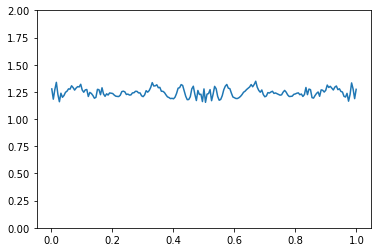

: 

In [37]:
ax = plt.gca()
plt.plot(ps, np.array(aveQueryNum_FinalRedo) / np.array(aveQueryNum))
ax.set_ylim(0,2)
plt.show()